In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dfB=pd.read_csv('Bozeman_limpio_final.csv')
dfB.head()


,Unnamed: 0.1,Unnamed: 0,last_scraped,source,name,description,host_name,host_since,host_location,host_about,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,reviews_per_month
0,0,0,09/11/2024,city scrape,Unique neighborhood cottage,"Not for everyone, but loved by many'<br />' Th...",Stacie,29/05/2012,"Bozeman, MT",I love my home and love sharing it.,...,1.0,4.95,4.95,4.97,4.99,4.98,4.98,4.89,1.0,1.72
1,1,1,09/11/2024,city scrape,Downtown Bozeman Vacation Rental,Just four easy blocks from historic downtown B...,Brian,08/11/2013,"Bozeman, MT",I'm a born and raised Montanan. I've done some...,...,5.0,4.97,4.98,4.95,4.97,4.99,4.93,4.94,2.0,3.92
2,2,2,09/11/2024,city scrape,Northside Hideaway,"Free, fast Wi-Fi for remote learning/working n...",Paul,17/08/2013,"Bozeman, MT",I started Bozeman Cottage Vacation Rentals in ...,...,1.0,4.76,4.89,4.82,4.95,4.97,4.97,4.70,3.0,0.30
3,3,3,09/11/2024,city scrape,2 Blocks 2 Main,This space is designed for 1-2 people that wan...,Irene,31/07/2013,"Bozeman, MT",I have lived in or near Bozeman all of my life...,...,0.0,4.96,5.00,5.00,5.00,4.98,5.00,4.73,2.0,0.47
4,4,4,09/11/2024,city scrape,Modern Home Near Campus & Downtown,"Great house on the south side of town, near ca...",Kris And Alex,20/08/2013,"Livingston, MT",We have been traveling with Airbnb for the pas...,...,2.0,4.77,4.87,4.90,4.91,4.83,4.89,4.73,1.0,2.46


In [117]:
#dfB=dfB.drop('Unnamed: 0',axis=1)
#dfB=dfB.drop( 'Unnamed: 0.1',axis=1)
dfB.head()
dfB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0       last_scraped                567 non-null    object 
 1   source                          567 non-null    object 
 2   name                            567 non-null    object 
 3   description                     567 non-null    object 
 4   host_name                       567 non-null    object 
 5   host_since                      567 non-null    object 
 6   host_location                   567 non-null    object 
 7   host_about                      567 non-null    object 
 8   host_response_time              567 non-null    object 
 9   host_response_rate              567 non-null    object 
 10  host_acceptance_rate            567 non-null    float64
 11  host_is_superhost               567 non-null    object 
 12  host_verifications              567 

In [118]:
hotel_room_dfB = dfB[dfB['room_type'] == 'Hotel room']
entire_home_dfB = dfB[dfB['room_type'] == 'Entire home/apt']
private_room_dfB = dfB[dfB['room_type'] == 'Private room']
shared_room_dfB = dfB[dfB['room_type'] == 'Shared room'] 

In [119]:
#eliminamos colunas que no nos interesan
hotel_room_dfB.drop(hotel_room_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
entire_home_dfB.drop(entire_home_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
private_room_dfB.drop(private_room_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
shared_room_dfB.drop(shared_room_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)

C:\Users\jesus\AppData\Local\Temp\ipykernel_1360\3393999898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_room_dfB.drop(hotel_room_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
C:\Users\jesus\AppData\Local\Temp\ipykernel_1360\3393999898.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entire_home_dfB.drop(entire_home_dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
C:\Users\jesus\AppData\Local\Temp\ipykernel_1360\3393999898.py:4: Settin

In [120]:
Vars_Indep_hotel_room = hotel_room_dfB[['host_acceptance_rate']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_hotel_room = hotel_room_dfB['price']

<Axes: xlabel='host_acceptance_rate', ylabel='price'>

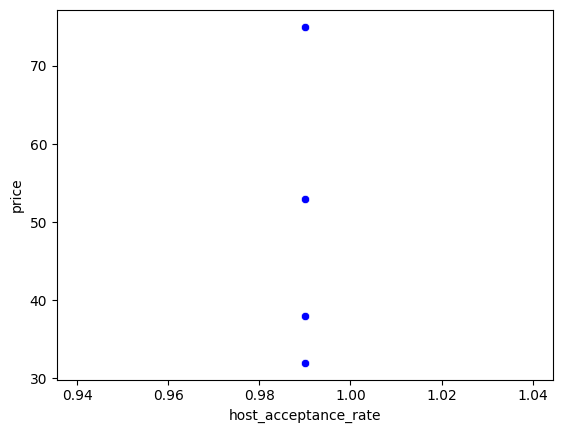

In [121]:
from turtle import color   
sns.scatterplot(x='host_acceptance_rate',y='price',color='blue',data=hotel_room_dfB)

In [122]:

#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [123]:
type(model)

sklearn.linear_model._base.LinearRegression

In [124]:
model.fit(X=Vars_Indep_hotel_room, y=Var_Dep_hotel_room)

LinearRegression()

In [125]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.]),
 'rank_': 0,
 'singular_': array([0.]),
 'intercept_': np.float64(49.5)}

In [126]:
model.score(Vars_Indep_hotel_room,Var_Dep_hotel_room)


0.0

In [127]:
y_pred_hotel_room=model.predict(X=hotel_room_dfB[['host_acceptance_rate']])
y_pred_hotel_room

array([49.5, 49.5, 49.5, 49.5])

In [128]:
hotel_room_dfB.insert(0,'predicciones_hotel_room',y_pred_hotel_room)
hotel_room_dfB

,predicciones_hotel_room,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,price,instant_bookable,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
27,49.5,0.99,f,t,Room in hostel,Hotel room,32.0,f,5.0,6.0,2.5,1,4.9,4.80,3.26
28,49.5,0.99,f,t,Room in hostel,Hotel room,53.0,f,5.0,1.0,2.5,1,4.9,4.74,2.21
30,49.5,0.99,f,t,Room in hostel,Hotel room,38.0,t,5.0,4.0,2.5,1,4.9,4.90,2.17
35,49.5,0.99,f,t,Room in hostel,Hotel room,75.0,f,5.0,2.0,2.5,1,4.9,4.90,1.45


In [47]:
hotel_room_dfB=hotel_room_dfB.drop( 'predicciones',axis=1)

In [48]:
hotel_room_dfB=hotel_room_dfB.drop( 'predicciones_hotel_room',axis=1)

<Axes: xlabel='host_acceptance_rate', ylabel='price'>

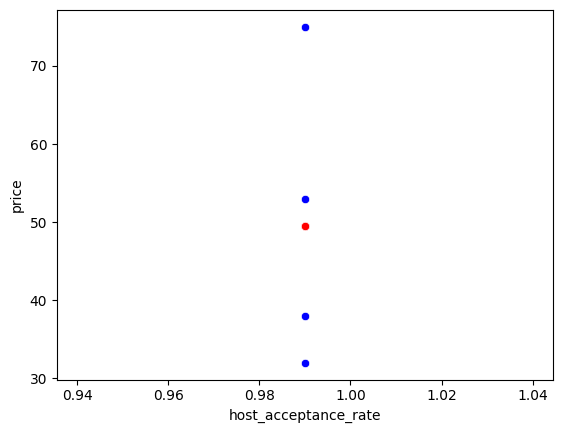

In [50]:
sns.scatterplot(x='host_acceptance_rate',y='price',color='blue',data=hotel_room_dfB)
sns.scatterplot(x='host_acceptance_rate',y='predicciones_hotel_room',color='red',data=hotel_room_dfB)
sns.lineplot(x='host_acceptance_rate',y='predicciones_hotel_room',color='red',data=hotel_room_dfB)

In [91]:
coef_Deter_hotel_room=model.score(X=Vars_Indep_hotel_room, y=Var_Dep_hotel_room)
coef_Deter_hotel_room

-11.617793514183624

In [92]:
coef_Correl_hotel_room=np.sqrt(coef_Deter_hotel_room)
coef_Correl_hotel_room

C:\Users\jesus\AppData\Local\Temp\ipykernel_1360\2350641475.py:1: RuntimeWarning: invalid value encountered in sqrt
  coef_Correl_hotel_room=np.sqrt(coef_Deter_hotel_room)


np.float64(nan)

In [18]:
hotel_room_dfB.host_response_rate = hotel_room_dfB.host_response_rate.replace({'09/11/2024':'49.5'}, regex=False)

C:\Users\jesus\AppData\Local\Temp\ipykernel_1360\665962708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_room_dfB.host_response_rate = hotel_room_dfB.host_response_rate.replace({'09/11/2024':'49.5'}, regex=False)


In [93]:
import numpy as np

numeric_df_hotel_room = hotel_room_dfB.select_dtypes(include=[np.number])
Corr_Factors_hotel_room = numeric_df_hotel_room.corr()
print(Corr_Factors_hotel_room)

                                predicciones_hotel_room  Unnamed: 0  \
predicciones_hotel_room                             NaN         NaN   
Unnamed: 0                                          NaN    1.000000   
host_acceptance_rate                                NaN         NaN   
price                                               NaN    0.845786   
host_listings_count                                 NaN         NaN   
host_total_listings_count                           NaN         NaN   
accommodates                                        NaN   -0.422389   
bathrooms                                           NaN         NaN   
bedrooms                                            NaN         NaN   
beds                                                NaN   -0.198680   
minimum_nights                                      NaN         NaN   
maximum_nights                                      NaN   -0.486664   
minimum_nights_avg_ntm                              NaN         NaN   
maximu

In [95]:
Corr_Factors_hotel_room1=abs(Corr_Factors_hotel_room)
Corr_Factors_hotel_room1

,predicciones_hotel_room,Unnamed: 0,host_acceptance_rate,price,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,reviews_per_month
predicciones_hotel_room,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 0,NaN,1.000000,NaN,0.845786,NaN,NaN,0.422389,NaN,NaN,0.198680,...,0.374634,NaN,0.108270,NaN,0.136293,0.591344,0.523743,0.735494,NaN,0.873465
host_acceptance_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,NaN,0.845786,NaN,1.000000,NaN,NaN,0.757247,NaN,NaN,0.639785,...,0.121799,NaN,0.459759,NaN,0.054861,0.615999,0.797443,0.262260,NaN,0.870782
host_listings_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_total_listings_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,NaN,0.422389,NaN,0.757247,NaN,NaN,1.000000,NaN,NaN,0.531494,...,0.676481,NaN,0.198608,NaN,0.528673,0.016949,0.447736,0.161846,NaN,0.768063
bathrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
beds,NaN,0.198680,NaN,0.639785,NaN,NaN,0.531494,NaN,NaN,1.000000,...,0.471405,NaN,0.934199,NaN,0.342997,0.637793,0.916909,0.477665,NaN,0.215073


 ENTIRE HOME 

In [55]:
Vars_Indep_entire_home = entire_home_dfB[['host_acceptance_rate']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_entire_home = entire_home_dfB['price']

In [56]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [57]:
type(model)

sklearn.linear_model._base.LinearRegression

In [58]:
model.fit(X=Vars_Indep_entire_home, y=Var_Dep_entire_home)

LinearRegression()

In [59]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-21.64212406]),
 'rank_': 1,
 'singular_': array([3.75341282]),
 'intercept_': np.float64(227.02342108276014)}

In [60]:
model.score(Vars_Indep_entire_home,Var_Dep_entire_home)

0.0006800270718103629

In [61]:
y_pred_entire_home=model.predict(X=entire_home_dfB[['host_acceptance_rate']])
y_pred_entire_home

array([207.11266695, 205.38129702, 205.59771826, 207.11266695,
       205.38129702, 218.36657146, 206.46340323, 207.32908819,
       205.38129702, 205.38129702, 227.02342108, 205.38129702,
       205.38129702, 206.46340323, 205.38129702, 205.38129702,
       205.38129702, 205.38129702, 210.79182804, 205.38129702,
       205.38129702, 205.38129702, 205.38129702, 205.38129702,
       205.38129702, 206.46340323, 205.59771826, 205.38129702,
       209.06045811, 205.38129702, 205.38129702, 205.38129702,
       205.59771826, 205.38129702, 205.38129702, 206.46340323,
       205.38129702, 205.38129702, 205.38129702, 205.38129702,
       205.8141395 , 216.20235905, 205.59771826, 205.8141395 ,
       205.38129702, 205.38129702, 205.38129702, 206.24698199,
       205.38129702, 207.11266695, 205.59771826, 205.38129702,
       205.38129702, 205.59771826, 221.82931131, 205.38129702,
       205.38129702, 205.38129702, 205.59771826, 221.82931131,
       205.38129702, 205.59771826, 206.46340323, 205.38

In [ ]:
entire_home_dfB.insert(0,'predicciones_entire_home',y_pred_entire_home)
entire_home_dfB


<Axes: xlabel='host_response_rate', ylabel='price'>

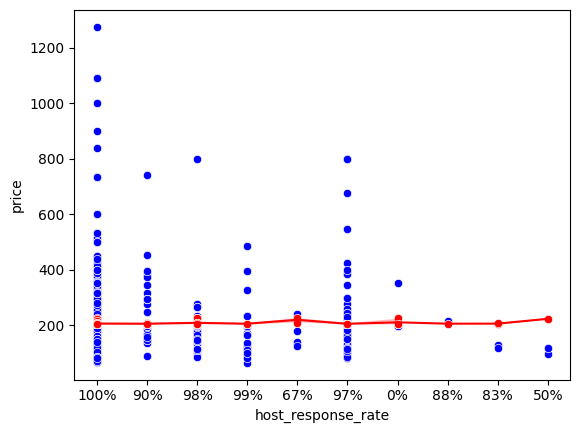

In [ ]:

sns.scatterplot(x='host_response_rate',y='price',color="blue",data=entire_home_dfB)
sns.scatterplot(x='host_response_rate',y='predicciones_entire_home',color="red",data=entire_home_dfB)
sns.lineplot(x='host_response_rate',y='predicciones_entire_home',color="red",data=entire_home_dfB)

In [69]:
coef_Deter_entire_home=model.score(X=Vars_Indep_entire_home, y=Var_Dep_entire_home)
coef_Deter_entire_home

0.0006800270718103629

In [70]:
coef_Correl_entire_home=np.sqrt(coef_Deter_entire_home)
coef_Correl_entire_home

np.float64(0.026077328693912705)

In [88]:
import numpy as np

numeric_df_entire_home = entire_home_dfB.select_dtypes(include=[np.number])
Corr_Factors_entire_home = numeric_df_entire_home.corr()
print(Corr_Factors_entire_home)

                                predicciones_entire_home  Unnamed: 0  \
predicciones_entire_home                        1.000000   -0.013151   
Unnamed: 0                                     -0.013151    1.000000   
host_acceptance_rate                           -1.000000    0.013151   
price                                           0.026077   -0.013657   
host_listings_count                            -0.164661    0.266198   
host_total_listings_count                      -0.156766    0.229816   
accommodates                                   -0.030303    0.062285   
bathrooms                                       0.068457    0.102955   
bedrooms                                        0.110366    0.037763   
beds                                           -0.020026   -0.045812   
minimum_nights                                  0.257345    0.115454   
maximum_nights                                 -0.131570   -0.225062   
minimum_nights_avg_ntm                          0.236791    0.14

In [ ]:
#Corr_Factors_entire_home=entire_home_dfB.corr()
#Corr_Factors_entire_home

In [89]:
Corr_Factors_entire_home1=abs(Corr_Factors_entire_home)
Corr_Factors_entire_home1

,predicciones_entire_home,Unnamed: 0,host_acceptance_rate,price,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,reviews_per_month
predicciones_entire_home,1.000000,0.013151,1.000000,0.026077,0.164661,0.156766,0.030303,0.068457,0.110366,0.020026,...,0.087746,0.047654,0.001955,0.027331,0.029471,0.002762,0.018361,0.008102,0.151279,0.108271
Unnamed: 0,0.013151,1.000000,0.013151,0.013657,0.266198,0.229816,0.062285,0.102955,0.037763,0.045812,...,0.107830,0.068726,0.000309,0.010899,0.134194,0.098048,0.064710,0.054408,0.153236,0.094571
host_acceptance_rate,1.000000,0.013151,1.000000,0.026077,0.164661,0.156766,0.030303,0.068457,0.110366,0.020026,...,0.087746,0.047654,0.001955,0.027331,0.029471,0.002762,0.018361,0.008102,0.151279,0.108271
price,0.026077,0.013657,0.026077,1.000000,0.037604,0.065144,0.344816,0.340453,0.487536,0.195240,...,0.182264,0.096644,0.025365,0.038190,0.055554,0.100016,0.090349,0.067064,0.007543,0.245282
host_listings_count,0.164661,0.266198,0.164661,0.037604,1.000000,0.968267,0.041083,0.060100,0.023692,0.029632,...,0.120019,0.026157,0.016243,0.028758,0.013946,0.031489,0.021495,0.014709,0.391566,0.064333
host_total_listings_count,0.156766,0.229816,0.156766,0.065144,0.968267,1.000000,0.028817,0.049962,0.019386,0.018595,...,0.161022,0.009635,0.009595,0.056807,0.019311,0.050057,0.029739,0.011307,0.329927,0.123886
accommodates,0.030303,0.062285,0.030303,0.344816,0.041083,0.028817,1.000000,0.566899,0.737480,0.649578,...,0.146323,0.008592,0.018094,0.040459,0.050078,0.059274,0.068312,0.019072,0.087366,0.075093
bathrooms,0.068457,0.102955,0.068457,0.340453,0.060100,0.049962,0.566899,1.000000,0.670806,0.457587,...,0.291955,0.101636,0.046180,0.027161,0.084708,0.057596,0.004191,0.049618,0.087934,0.301317
bedrooms,0.110366,0.037763,0.110366,0.487536,0.023692,0.019386,0.737480,0.670806,1.000000,0.546596,...,0.219390,0.080495,0.012041,0.008553,0.124491,0.030678,0.003876,0.000570,0.030752,0.223964
beds,0.020026,0.045812,0.020026,0.195240,0.029632,0.018595,0.649578,0.457587,0.546596,1.000000,...,0.126859,0.060798,0.098736,0.095987,0.013244,0.109273,0.044370,0.020320,0.102029,0.056556


<Axes: >

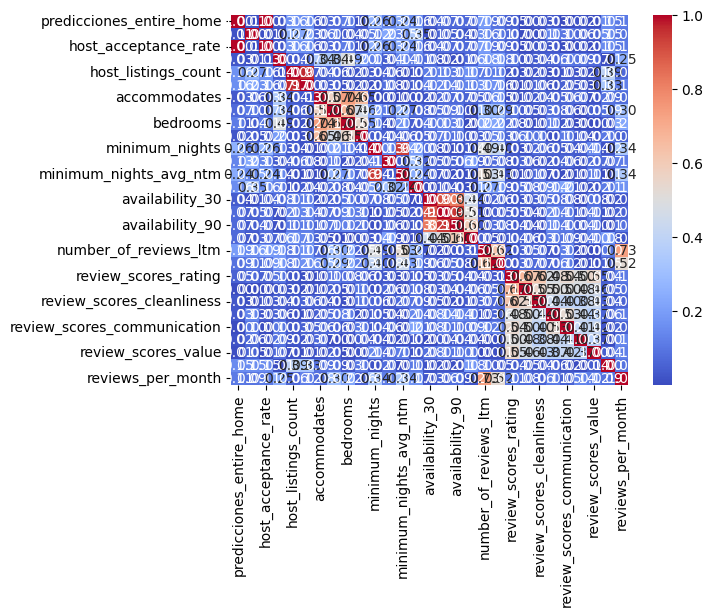

In [90]:
Heat_map=sns.heatmap(Corr_Factors_entire_home1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map

PRIVATE ROOM 

In [76]:
Vars_Indep_private_room = private_room_dfB[['host_acceptance_rate']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_private_room = private_room_dfB['price']

In [77]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [78]:
type(model)

sklearn.linear_model._base.LinearRegression

In [79]:
model.fit(X=Vars_Indep_private_room, y=Var_Dep_private_room)

LinearRegression()

In [80]:
model.__dict__


{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([75.83352195]),
 'rank_': 1,
 'singular_': array([0.6739356]),
 'intercept_': np.float64(30.973886332227536)}

In [81]:
model.score(Vars_Indep_private_room,Var_Dep_private_room)


0.025874836799979484

In [82]:
y_pred_private_room=model.predict(X=private_room_dfB[['host_acceptance_rate']])
y_pred_private_room

array([103.01573219, 106.80740829, 106.04907307, 105.29073785,
       106.04907307, 103.01573219, 100.74072653, 106.80740829,
       106.04907307,  55.99894858, 103.01573219, 105.29073785,
       101.49906175, 101.49906175, 103.77406741, 106.80740829,
       106.80740829, 106.80740829, 106.80740829, 106.80740829,
       103.77406741,  90.88236868, 105.29073785, 106.80740829,
       106.80740829, 106.80740829, 106.80740829, 106.80740829,
       106.04907307, 106.04907307, 103.01573219, 101.49906175,
       101.49906175, 103.01573219, 101.49906175, 101.49906175,
       103.01573219])

In [ ]:
private_room_dfB.insert(0,'predicciones_private_room',y_pred_private_room)
private_room_dfB

In [84]:
coef_Deter_private_room=model.score(X=Vars_Indep_private_room, y=Var_Dep_private_room)
coef_Deter_private_room

0.025874836799979484

In [85]:
coef_Correl_private_room=np.sqrt(coef_Deter_private_room)
coef_Correl_private_room

np.float64(0.16085657213797477)

In [97]:
import numpy as np

numeric_df_private_room = private_room_dfB.select_dtypes(include=[np.number])
Corr_Factors_private_room = numeric_df_private_room.corr()
print(Corr_Factors_private_room)

                                predicciones_private_room  Unnamed: 0  \
predicciones_private_room                        1.000000    0.017016   
Unnamed: 0                                       0.017016    1.000000   
host_acceptance_rate                             1.000000    0.017016   
price                                            0.160857    0.052562   
host_listings_count                              0.083123    0.422863   
host_total_listings_count                       -0.007865    0.364763   
accommodates                                    -0.138329    0.085481   
bathrooms                                        0.164946    0.120235   
bedrooms                                        -0.422520    0.134398   
beds                                            -0.023163    0.212372   
minimum_nights                                  -0.354397    0.134114   
maximum_nights                                   0.136167    0.053199   
minimum_nights_avg_ntm                          -0.

In [98]:
Corr_Factors_private_room1=abs(Corr_Factors_private_room)
Corr_Factors_private_room1

,predicciones_private_room,Unnamed: 0,host_acceptance_rate,price,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,reviews_per_month
predicciones_private_room,1.000000,0.017016,1.000000,0.160857,0.083123,0.007865,0.138329,0.164946,4.225196e-01,0.023163,...,0.119765,0.154615,0.095354,0.125866,0.024135,0.002786,1.611099e-01,0.206179,0.112647,0.265389
Unnamed: 0,0.017016,1.000000,0.017016,0.052562,0.422863,0.364763,0.085481,0.120235,1.343982e-01,0.212372,...,0.235579,0.006939,0.160711,0.031203,0.111703,0.146385,2.241280e-01,0.202058,0.490448,0.110921
host_acceptance_rate,1.000000,0.017016,1.000000,0.160857,0.083123,0.007865,0.138329,0.164946,4.225196e-01,0.023163,...,0.119765,0.154615,0.095354,0.125866,0.024135,0.002786,1.611099e-01,0.206179,0.112647,0.265389
price,0.160857,0.052562,0.160857,1.000000,0.045037,0.202552,0.603021,0.639410,2.341494e-01,0.702321,...,0.045777,0.110721,0.079864,0.161329,0.228749,0.327908,1.099050e-01,0.015351,0.060312,0.250306
host_listings_count,0.083123,0.422863,0.083123,0.045037,1.000000,0.936750,0.016043,0.208011,1.141358e-01,0.203181,...,0.307204,0.035252,0.078853,0.088048,0.079621,0.007196,6.593313e-02,0.221327,0.923146,0.129291
host_total_listings_count,0.007865,0.364763,0.007865,0.202552,0.936750,1.000000,0.161619,0.095294,1.020011e-01,0.081864,...,0.331704,0.040008,0.045961,0.027471,0.141129,0.021661,4.333506e-02,0.159937,0.883367,0.207121
accommodates,0.138329,0.085481,0.138329,0.603021,0.016043,0.161619,1.000000,0.339236,5.113294e-01,0.728489,...,0.063977,0.275779,0.142062,0.039754,0.481940,0.425216,1.188520e-01,0.026498,0.047767,0.244351
bathrooms,0.164946,0.120235,0.164946,0.639410,0.208011,0.095294,0.339236,1.000000,9.044964e-02,0.668636,...,0.061775,0.073880,0.016999,0.019132,0.080112,0.181484,7.287491e-02,0.237169,0.281502,0.295134
bedrooms,0.422520,0.134398,0.422520,0.234149,0.114136,0.102001,0.511329,0.090450,1.000000e+00,0.531262,...,0.201076,0.049663,0.056042,0.113742,0.239745,0.198777,1.504382e-15,0.045017,0.151845,0.348869
beds,0.023163,0.212372,0.023163,0.702321,0.203181,0.081864,0.728489,0.668636,5.312619e-01,1.000000,...,0.018326,0.104850,0.067570,0.023807,0.214655,0.236708,2.608194e-02,0.083191,0.298684,0.368512


SHARED ROOM

In [99]:
Vars_Indep_shared_room = shared_room_dfB[['host_acceptance_rate']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_shared_room = shared_room_dfB['price']

In [100]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [101]:
type(model)

sklearn.linear_model._base.LinearRegression

In [102]:
model.fit(X=Vars_Indep_shared_room, y=Var_Dep_shared_room)

LinearRegression()

In [103]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.]),
 'rank_': 0,
 'singular_': array([0.]),
 'intercept_': np.float64(40.0)}

In [105]:
model.score(Vars_Indep_shared_room,Var_Dep_shared_room)

c:\Users\jesus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [106]:
y_pred_shared_room=model.predict(X=shared_room_dfB[['host_acceptance_rate']])
y_pred_shared_room

array([40.])

In [107]:
shared_room_dfB.insert(0,'predicciones_shared_room',y_pred_shared_room)
shared_room_dfB

,predicciones_shared_room,Unnamed: 0,last_scraped,source,name,description,host_name,host_since,host_location,host_about,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,reviews_per_month
31,40.0,31,09/11/2024,city scrape,Treasure State Hostel 3 Bed Dorm,"We are a safe, clean, and affordable hostel lo...",Nina,23/11/2015,"Bozeman, MT",Hello! I've been an airbnb host and traveler f...,...,2.0,4.9,4.78,4.9,4.8,4.85,4.83,4.7,5.0,0.94


In [108]:
coef_Deter_shared_room=model.score(X=Vars_Indep_shared_room, y=Var_Dep_shared_room)
coef_Deter_shared_room


c:\Users\jesus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [109]:
coef_Correl_shared_room=np.sqrt(coef_Deter_shared_room)
coef_Correl_shared_room

np.float64(nan)

In [111]:
import numpy as np

numeric_df_shared_room = hotel_room_dfB.select_dtypes(include=[np.number])
Corr_Factors_shared_room = numeric_df_shared_room.corr()
print(Corr_Factors_hotel_room)


                                predicciones_hotel_room  Unnamed: 0  \
predicciones_hotel_room                             NaN         NaN   
Unnamed: 0                                          NaN    1.000000   
host_acceptance_rate                                NaN         NaN   
price                                               NaN    0.845786   
host_listings_count                                 NaN         NaN   
host_total_listings_count                           NaN         NaN   
accommodates                                        NaN   -0.422389   
bathrooms                                           NaN         NaN   
bedrooms                                            NaN         NaN   
beds                                                NaN   -0.198680   
minimum_nights                                      NaN         NaN   
maximum_nights                                      NaN   -0.486664   
minimum_nights_avg_ntm                              NaN         NaN   
maximu

In [112]:

Corr_Factors_shared_room1=abs(Corr_Factors_shared_room)
Corr_Factors_shared_room1

,predicciones_hotel_room,Unnamed: 0,host_acceptance_rate,price,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,reviews_per_month
predicciones_hotel_room,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 0,NaN,1.000000,NaN,0.845786,NaN,NaN,0.422389,NaN,NaN,0.198680,...,0.374634,NaN,0.108270,NaN,0.136293,0.591344,0.523743,0.735494,NaN,0.873465
host_acceptance_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,NaN,0.845786,NaN,1.000000,NaN,NaN,0.757247,NaN,NaN,0.639785,...,0.121799,NaN,0.459759,NaN,0.054861,0.615999,0.797443,0.262260,NaN,0.870782
host_listings_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_total_listings_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,NaN,0.422389,NaN,0.757247,NaN,NaN,1.000000,NaN,NaN,0.531494,...,0.676481,NaN,0.198608,NaN,0.528673,0.016949,0.447736,0.161846,NaN,0.768063
bathrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
beds,NaN,0.198680,NaN,0.639785,NaN,NaN,0.531494,NaN,NaN,1.000000,...,0.471405,NaN,0.934199,NaN,0.342997,0.637793,0.916909,0.477665,NaN,0.215073


In [94]:
dfM=pd.read_csv('Datos_limpios_Mexico.csv')
dfM=dfM.drop('Unnamed: 0',axis=1)
dfM.head()
dfM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26582 entries, 0 to 26581
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   last_scraped                    26582 non-null  object 
 1   source                          26582 non-null  object 
 2   name                            26582 non-null  object 
 3   description                     26582 non-null  object 
 4   host_name                       26582 non-null  object 
 5   host_since                      26582 non-null  object 
 6   host_location                   26582 non-null  object 
 7   host_about                      26582 non-null  object 
 8   host_response_time              26582 non-null  object 
 9   host_response_rate              26582 non-null  object 
 10  host_acceptance_rate            26582 non-null  object 
 11  host_is_superhost               26582 non-null  object 
 12  host_verifications              

In [95]:
hotel_room_dfM = dfM[dfM['room_type'] == 'Hotel room']
entire_home_dfM = dfM[dfM['room_type'] == 'Entire home/apt']
private_room_dfM = dfM[dfM['room_type'] == 'Private room']
shared_room_dfM = dfM[dfM['room_type'] == 'Shared room'] 

<Axes: xlabel='room_type', ylabel='price'>

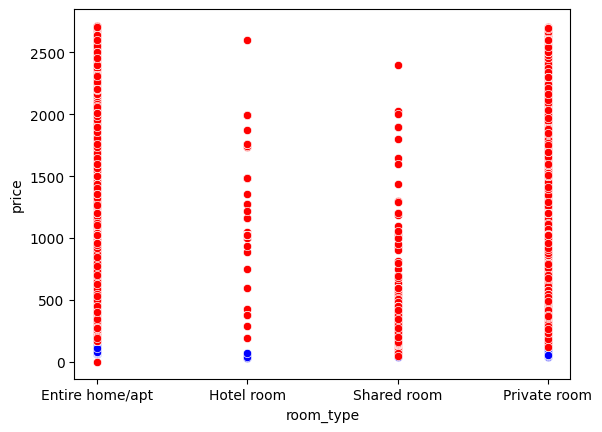

In [ ]:
#comparadno mexico con bozeman
sns.scatterplot(x='room_type', y='price', color='blue', data=dfB)
sns.scatterplot(x='room_type', y='price', color='red', data=dfM)

In [ ]:
sns.scatterplot(x='room_type', y='price', color='blue', data=dfB)
sns.scatterplot(x='room_type', y='price', color='red', data=dfM)